In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")
print(f"Pandas version: {pd.__version__}")

All imports successful!
Pandas version: 3.0.1


In [4]:
AMAZON_PATH = "/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/raw/amazon_unlocked_mobile.csv"

df_amazon = pd.read_csv(AMAZON_PATH, low_memory=False)

print(f"Shape: {df_amazon.shape}")
print(f"\nColumn names: {df_amazon.columns.tolist()}")
print(f"\nFirst 3 rows:")
df_amazon.head(3)

Shape: (413840, 6)

Column names: ['product_name', 'brand_name', 'price', 'rating', 'reviews', 'review_votes']

First 3 rows:


,product_name,brand_name,price,rating,reviews,review_votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0


In [5]:
REVIEWS_PATH = "/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/raw/20191226-reviews.csv"
ITEMS_PATH = "/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/raw/20191226-items.csv"

df_reviews = pd.read_csv(REVIEWS_PATH, low_memory=False)
df_items = pd.read_csv(ITEMS_PATH, low_memory=False)

print(f"Reviews shape: {df_reviews.shape}")
print(f"Items shape: {df_items.shape}")

df_scraped = df_reviews.merge(
    df_items[['asin', 'brand', 'title', 'price', 'originalPrice']],
    on='asin',
    how='left'
)

print(f"\nMerged scraped shape: {df_scraped.shape}")
print(f"Brand coverage: {df_scraped['brand'].notna().sum():,} of {len(df_scraped):,} reviews have a brand")

Reviews shape: (67986, 8)
Items shape: (720, 10)

Merged scraped shape: (67986, 12)
Brand coverage: 67,786 of 67,986 reviews have a brand


In [6]:
df_amazon_clean = df_amazon.rename(columns={
    'product_name': 'product_title',
    'brand_name': 'brand',
    'reviews': 'review_body',
    'review_votes': 'helpful_votes'
})

df_amazon_clean['source'] = 'amazon_unlocked'
df_amazon_clean['review_title'] = None
df_amazon_clean['review_date'] = None
df_amazon_clean['verified_purchase'] = None

df_scraped_clean = df_scraped.rename(columns={
    'title_x': 'review_title',
    'title_y': 'product_title',
    'body': 'review_body',
    'date': 'review_date',
    'verified': 'verified_purchase',
    'helpfulVotes': 'helpful_votes'
})
df_scraped_clean['source'] = 'scraped_2019'

KEEP_COLS = ['source', 'brand', 'product_title', 'price', 'rating',
             'review_title', 'review_body', 'review_date',
             'verified_purchase', 'helpful_votes']

df_amazon_final = df_amazon_clean[[c for c in KEEP_COLS if c in df_amazon_clean.columns]]
df_scraped_final = df_scraped_clean[[c for c in KEEP_COLS if c in df_scraped_clean.columns]]

print("Amazon columns:", df_amazon_final.columns.tolist())
print("Scraped columns:", df_scraped_final.columns.tolist())

Amazon columns: ['source', 'brand', 'product_title', 'price', 'rating', 'review_title', 'review_body', 'review_date', 'verified_purchase', 'helpful_votes']
Scraped columns: ['source', 'brand', 'product_title', 'price', 'rating', 'review_title', 'review_body', 'review_date', 'verified_purchase', 'helpful_votes']


In [7]:
df_master = pd.concat([df_amazon_final, df_scraped_final], ignore_index=True)

print(f"Master dataset shape: {df_master.shape}")
print(f"\nNull values per column:")
print(df_master.isnull().sum())

Master dataset shape: (481826, 10)

Null values per column:
source                    0
brand                 65371
product_title             0
price                  5933
rating                    0
review_title         413869
review_body              96
review_date          413840
verified_purchase    413840
helpful_votes         53067
dtype: int64


In [8]:
brand_map = {
    'Apple': 'Apple',
    'Samsung': 'Samsung',
    'samsung': 'Samsung',
    'Google': 'Google',
    'OnePlus': 'OnePlus',
    'Xiaomi': 'Xiaomi',
    'Motorola': 'Motorola',
    'LG': 'LG',
    'LG Electronics': 'LG',
    'Nokia': 'Nokia',
    'Huawei': 'Huawei',
    'HUAWEI': 'Huawei',
}

TARGET_BRANDS = ['Apple', 'Samsung', 'Google', 'OnePlus', 'Xiaomi',
                 'Motorola', 'LG', 'Nokia', 'Huawei']

df_master['brand'] = df_master['brand'].map(brand_map)
df_filtered = df_master[df_master['brand'].isin(TARGET_BRANDS)].copy()

print(f"After brand filter: {df_filtered.shape}")
print("\nReviews per brand:")
print(df_filtered['brand'].value_counts())

After brand filter: (250818, 10)

Reviews per brand:
brand
Samsung     101807
Apple        63331
LG           25522
Nokia        22721
Motorola     22297
Huawei        6101
Xiaomi        4430
Google        3824
OnePlus        785
Name: count, dtype: int64


In [9]:
df_filtered.dropna(subset=['brand', 'rating', 'review_body'], inplace=True)

before = len(df_filtered)
df_filtered.drop_duplicates(subset=['brand', 'review_body'], inplace=True)
after = len(df_filtered)

print(f"Removed {before - after:,} duplicate rows")
print(f"Final master dataset: {df_filtered.shape}")
print(f"\nRating distribution:")
print(df_filtered['rating'].value_counts().sort_index())

Removed 113,361 duplicate rows
Final master dataset: (137388, 10)

Rating distribution:
rating
1    26725
2     8490
3    10665
4    19811
5    71697
Name: count, dtype: int64


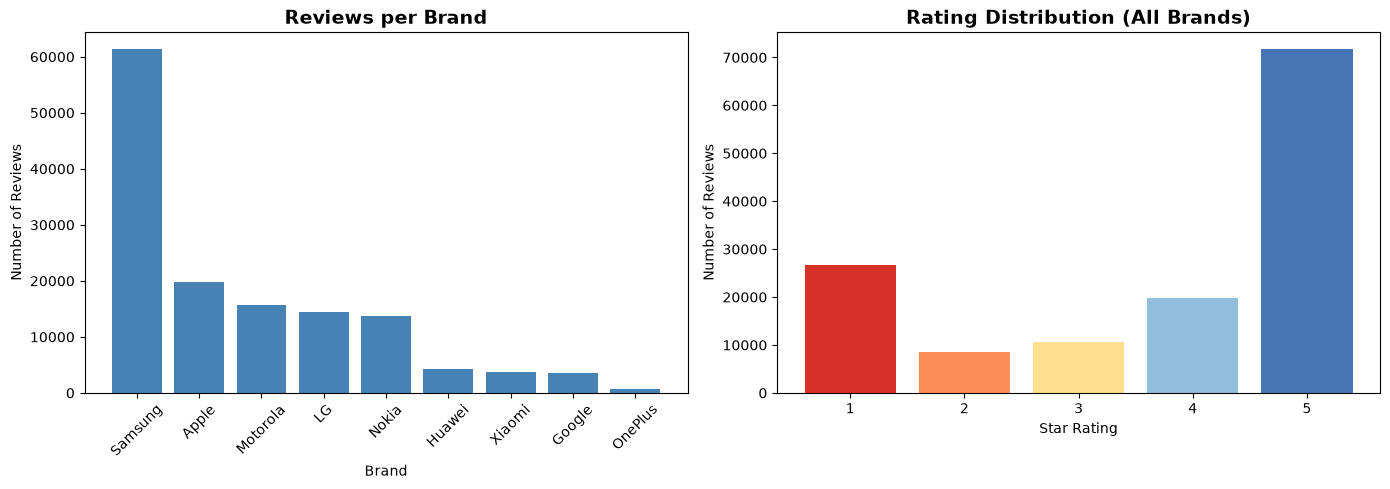

Chart saved to reports/


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

brand_counts = df_filtered['brand'].value_counts()
axes[0].bar(brand_counts.index, brand_counts.values, color='steelblue')
axes[0].set_title('Reviews per Brand', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=45)

rating_counts = df_filtered['rating'].value_counts().sort_index()
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
axes[1].bar(rating_counts.index, rating_counts.values, color=colors)
axes[1].set_title('Rating Distribution (All Brands)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Number of Reviews')

plt.tight_layout()
plt.savefig('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/reports/01_brand_and_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/")

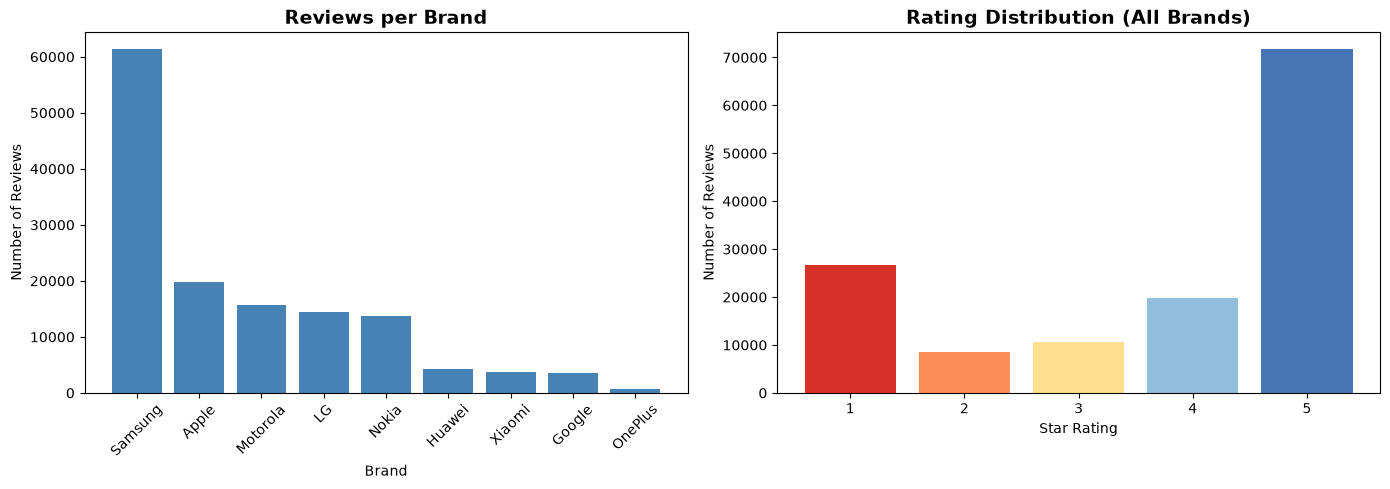

Chart saved to reports/


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

brand_counts = df_filtered['brand'].value_counts()
axes[0].bar(brand_counts.index, brand_counts.values, color='steelblue')
axes[0].set_title('Reviews per Brand', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=45)

rating_counts = df_filtered['rating'].value_counts().sort_index()
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
axes[1].bar(rating_counts.index, rating_counts.values, color=colors)
axes[1].set_title('Rating Distribution (All Brands)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Number of Reviews')

plt.tight_layout()
plt.savefig('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/reports/01_brand_and_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/")

In [12]:
OUTPUT_PATH = "/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/processed/master_reviews.csv"
df_filtered.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(df_filtered):,} rows to {OUTPUT_PATH}")
print("\nColumn preview:")
print(df_filtered.dtypes)

Saved 137,388 rows to /Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/processed/master_reviews.csv

Column preview:
source                   str
brand                    str
product_title            str
price                float64
rating                 int64
review_title          object
review_body              str
review_date           object
verified_purchase     object
helpful_votes        float64
dtype: object
